In [2]:
import pandas as pd

# Import du dataset
CSV_PATH = "friches-standard-2026-06-15.csv"
df = pd.read_csv(CSV_PATH, sep=";", low_memory=False)

# Comme exprimer dans le rapport annexe, l'objectif : je suis un investisseur et je cherche une friche que je peux racheter afin de la réhabilité pour en faire un grand espace culturel. 

print("shape:", df.shape) # affiche le nombre de lignes et nombre de colonnes
df.head() # affiche les 5 premières lignes

shape: (36241, 50)


,site_id,site_nom,site_type,site_adresse,site_identif_date,site_actu_date,site_url,site_ademe_url,site_securite,site_occupation,...,urba_zone_formdomi,urba_doc_type,desserte_distance,desserte_commentaire,source_nom,source_url,source_producteur,source_contact,geompoint,geomsurf
0,14118_22476,SARL l'Honneur,autre,NaN,2018-05-14,NaN,NaN,NaN,NaN,NaN,...,NaN,PLU,NaN,NaN,NaN,NaN,EPF Normandie,NaN,POINT (-0.3387695 49.18237),NaN
1,72211_39710,DDT 72-72211_39710,friche d'habitat,NaN,2026-01-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,DDT 72,NaN,POINT (-0.1065502 48.24507),NaN
2,72256_39750,DDT 72-72256_39750,friche d'habitat,NaN,2026-01-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,DDT 72,NaN,POINT (-0.1154831 48.14093),NaN
3,72334_39814,DDT 72-72334_39814,friche d'habitat,NaN,2026-01-01,NaN,NaN,NaN,NaN,NaN,...,Habitat,PLU,NaN,NaN,NaN,NaN,DDT 72,NaN,POINT (-0.127886 48.18621),NaN
4,72334_39815,DDT 72-72334_39815,friche d'habitat,NaN,2026-01-01,NaN,NaN,NaN,NaN,NaN,...,Habitat,PLU,NaN,NaN,NaN,NaN,DDT 72,NaN,POINT (-0.1255669 48.1861),NaN


In [3]:
# Liste des colonnes et de leurs types
print(f"nombre de colonnes : {len(df.columns)}") # nombre de colonnes
print(df.columns.tolist()) # liste les noms des colonnes 
df.dtypes # liste leur types

nombre de colonnes : 50
['site_id', 'site_nom', 'site_type', 'site_adresse', 'site_identif_date', 'site_actu_date', 'site_url', 'site_ademe_url', 'site_securite', 'site_occupation', 'site_statut', 'site_projet_url', 'site_reconv_annee', 'site_reconv_type', 'activite_libelle', 'activite_code', 'activite_fin_annee', 'comm_nom', 'comm_insee', 'bati_type', 'bati_nombre', 'bati_surface', 'bati_pollution', 'bati_vacance', 'bati_patrimoine', 'bati_etat', 'local_ancien_annee', 'local_recent_annee', 'proprio_type', 'proprio_personne', 'proprio_nom', 'sol_pollution_annee', 'sol_pollution_existe', 'sol_pollution_origine', 'sol_pollution_commentaire', 'sol_depollution_fiche', 'unite_fonciere_surface', 'unite_fonciere_refcad', 'urba_zone_type', 'urba_zone_lib', 'urba_zone_formdomi', 'urba_doc_type', 'desserte_distance', 'desserte_commentaire', 'source_nom', 'source_url', 'source_producteur', 'source_contact', 'geompoint', 'geomsurf']


site_id                          str
site_nom                         str
site_type                        str
site_adresse                     str
site_identif_date                str
site_actu_date                   str
site_url                         str
site_ademe_url               float64
site_securite                    str
site_occupation                  str
site_statut                      str
site_projet_url              float64
site_reconv_annee            float64
site_reconv_type                 str
activite_libelle                 str
activite_code                    str
activite_fin_annee               str
comm_nom                         str
comm_insee                       str
bati_type                        str
bati_nombre                  float64
bati_surface                 float64
bati_pollution                   str
bati_vacance                     str
bati_patrimoine                  str
bati_etat                        str
local_ancien_annee           float64
l

In [4]:
# affichage des colonnes ayant des valeurs manquantes et à quel pourcentage
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_overview = pd.DataFrame({
    "missing": missing,
    "pct": missing_pct,
})
missing_overview.head(20)

,missing,pct
site_projet_url,36241,100.0
site_ademe_url,36241,100.0
site_reconv_annee,36241,100.0
geomsurf,36241,100.0
sol_pollution_annee,36241,100.0
desserte_distance,36241,100.0
desserte_commentaire,36241,100.0
bati_surface,36241,100.0
sol_depollution_fiche,36235,100.0
sol_pollution_commentaire,36218,99.9


In [5]:
# determiner les catégories courantes dans des colonnes qui nous interesse
# ici, le type, le statut (pour savoir si un projet est déjà en cours), l'occupation et la pollution du sol
cat_cols = [
    "site_type",
    "site_statut",
    "site_occupation",
    "sol_pollution_existe",
]

for col in cat_cols:
    print("=" * 50)
    print(col)
    print(df[col].value_counts(dropna=False).head(50))
    print()

site_type
site_type
inconnu                              15509
friche d'habitat                      8770
friche industrielle                   3566
friche commerciale                    2152
autre                                 1749
friche d'équipement public             897
mixte                                  789
friche agro-industrielle               700
friche ferroviaire                     488
friche loisir tourisme hôtellerie      463
friche logistique                      296
friche carrière ou mine                230
friche hospitalière                    212
friche militaire                       193
mixte - autre                          103
friche enseignement                     70
friche cultuelle                        40
friche aéroportuaire                     8
friche portuaire                         6
Name: count, dtype: int64

site_statut
site_statut
friche potentielle    14020
friche sans projet    13401
friche avec projet     7086
friche reconvertie     1734


In [6]:
## On va commencer le nettoyage des données

# on travaille avec une copie du dataset original
df_clean = df.copy()

before_rows, before_cols = df_clean.shape
print(f"Avant le nettoyage: {before_rows} lignes x {before_cols} colonnes")

# On retire les colonnes ayant 100% de cases vides
empty_cols = []
for col in df_clean.columns:
    if df_clean[col].isna().sum() == len(df_clean):
        empty_cols.append(col)

df_clean = df_clean.drop(columns=empty_cols)
print("Colonnes vides retirées:", len(empty_cols))
print(empty_cols)

# On vérifie qu'il n'y ai pas de doublons en vérifiant le site_id
n_dupes = df_clean["site_id"].duplicated().sum()
print("Nombre de doublons:", n_dupes)
print(f"Après nettoyage: {df_clean.shape[0]} rows x {df_clean.shape[1]} cols")

Avant le nettoyage: 36241 lignes x 50 colonnes
Colonnes vides retirées: 8
['site_ademe_url', 'site_projet_url', 'site_reconv_annee', 'bati_surface', 'sol_pollution_annee', 'desserte_distance', 'desserte_commentaire', 'geomsurf']
Nombre de doublons: 0
Après nettoyage: 36241 rows x 42 cols


In [7]:
# fonction de normalisation d'un texte : NaN, strip, lower
def normalize_text(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip().lower()
    return text if text else pd.NA # transforme les chaines vides en manquant


# les labels de la polution des sols sont irréguliers, voici un mapping clair
pollution_map = {
    "oui": "pollution avérée",
    "non": "pollution inexistante",
    "pollution supposee": "pollution supposée",
    "pollution supposée": "pollution supposée",
    "pollution inexistante": "pollution inexistante",
    "pollution averee": "pollution avérée",
    "pollution avérée": "pollution avérée",
    "pollution peu probable": "pollution peu probable",
    "pollution probable": "pollution probable",
    "pollution traitee": "pollution traitée",
    "pollution traitée": "pollution traitée",
    "inconnu": "inconnu",
}

# faute de frappe dans une catégorie de la colonne d'occupation
occupation_map = {
    "partiellemebt inoccupé": "partiellement inoccupé",
}

# commencons par normaliser les colonnes qui nous interessent
for col in ["site_type", "site_statut", "site_occupation", "sol_pollution_existe", "comm_nom"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(normalize_text)

# On applique le mapping sur la colonne de polution
df_clean["sol_pollution_existe"] = (
    df_clean["sol_pollution_existe"]
    .replace(pollution_map)
)

# pareil pour la faute de frappe dans la colonne d'occupation
df_clean["site_occupation"] = (
    df_clean["site_occupation"]
    .replace(occupation_map)
)

# On s'assure que les surfaces sont numériques
df_clean["unite_fonciere_surface"] = pd.to_numeric(
    df_clean["unite_fonciere_surface"], errors="coerce"
)

print("Avant/Après normalisation :")
print("Pollution Avant :")
print(df["sol_pollution_existe"].value_counts(dropna=False))
print()
print("Pollution Après :")
print(df_clean["sol_pollution_existe"].value_counts(dropna=False))
print()
print("Occupation après normalisation (il ne devrait plus y avoir la faute de frappe):")
print(df_clean["site_occupation"].value_counts(dropna=False))

Avant/Après normalisation :
Pollution Avant :
sol_pollution_existe
inconnu                   31315
pollution supposée         1354
pollution inexistante      1196
NaN                        1038
pollution peu probable      791
pollution avérée            516
pollution traitée            15
Oui                           6
non                           3
pollution probable            2
Non                           2
oui                           1
oui                           1
Pollution peu probable        1
Name: count, dtype: int64

Pollution Après :
sol_pollution_existe
inconnu                   31315
pollution supposée         1354
pollution inexistante      1201
NaN                        1038
pollution peu probable      792
pollution avérée            524
pollution traitée            15
pollution probable            2
Name: count, dtype: int64

Occupation après normalisation (il ne devrait plus y avoir la faute de frappe):
site_occupation
inconnu                                 

In [8]:
## On passe à la partie analyse des données

import matplotlib.pyplot as plt

# taille moyenne du terrain en fonction du type de friche
# cela va nous aidez à determiner le type de friche à privilégier pour avoir un grand espace sans trop de contraintes.
avg_by_type = (
    df_clean
    .groupby("site_type")
    .agg(
        n_sites=("site_id", "count"),
        surface_mean=("unite_fonciere_surface", "mean"),
        surface_median=("unite_fonciere_surface", "median"),
    )
    .sort_values("surface_mean", ascending=False)
)

print("Taille moyenne du terrain en fonction du site_type:")
avg_by_type.head(10)

Taille moyenne du terrain en fonction du site_type:


,n_sites,surface_mean,surface_median
site_type,,,
friche aéroportuaire,8,2.478698e+06,1171082.0
friche militaire,193,9.864298e+05,133545.0
friche carrière ou mine,230,5.893472e+05,56850.0
friche portuaire,6,4.693440e+05,232460.0
friche industrielle,3566,1.892290e+05,23406.0
friche d'équipement public,897,1.878223e+05,14879.0
friche ferroviaire,488,1.526902e+05,53621.5
friche logistique,296,1.449292e+05,15273.0
friche agro-industrielle,700,1.445904e+05,14687.5


In [19]:
# On va retenir les friches industrielles, logistiques et agro-industrielles et aéroportuaires.
# Car elles présententent parmis les plus grands espaces sans trop de contraintes budgetaires liées à la réhabilitation et pour aéroportuaires (pourquoi pas c'est marrant).

industrial_types = [
    "friche aéroportuaire",
    "friche industrielle",
    "friche logistique",
    "friche agro-industrielle",
]

MIN_SURFACE = 10000  # surface minimal recherchée (m2)

available_status = [
    "friche sans projet",
    "friche potentielle",
]

# candidates : le résultat du filtrage des données selon nos critères
candidates = df_clean[
    (df_clean["site_type"].isin(industrial_types))
    & (df_clean["unite_fonciere_surface"] >= MIN_SURFACE)
    & (df_clean["site_statut"].isin(available_status))
].copy()

print("Nombre de candidats:", len(candidates))
print()

# labels qu'on considere comme "pollue" / "occupe"
polluted_labels = [
    "pollution avérée",
    "pollution supposée",
    "pollution probable",
]
occupied_labels = [
    "occupé",
    "partiellement occupé",
    "occupation transitoire ou temporaire",
    "occupation illicite supposée",
    "occupation illicite avérée",
]

# Le pourcentage de chances d'avoir un sol pollue ou d'etre occupe, par type
rows = []
for t in industrial_types:
    sub = candidates[candidates["site_type"] == t]
    n = len(sub)

    if n == 0:
        pct_polluted = 0.0
        pct_occupied = 0.0
    else:
        n_polluted = sub["sol_pollution_existe"].isin(polluted_labels).sum()
        n_occupied = sub["site_occupation"].isin(occupied_labels).sum()
        pct_polluted = (n_polluted / n * 100).round(1)
        pct_occupied = (n_occupied / n * 100).round(1)

    rows.append({
        "site_type": t,
        "n_candidates": n,
        "pct_sol_pollue": pct_polluted,
        "pct_occupe": pct_occupied,
    })

risk_by_type = pd.DataFrame(rows).sort_values("pct_sol_pollue", ascending=False)

idx_pollution = risk_by_type["pct_sol_pollue"].idxmax()
idx_occupation = risk_by_type["pct_occupe"].idxmax()

print(
    "Plus de chances d'avoir un sol pollue :",
    risk_by_type.loc[idx_pollution, "site_type"],
    f"({risk_by_type.loc[idx_pollution, 'pct_sol_pollue']}%)",
)
print(
    "Plus de chances d'etre occupe :",
    risk_by_type.loc[idx_occupation, "site_type"],
    f"({risk_by_type.loc[idx_occupation, 'pct_occupe']}%)",
)

risk_by_type

Nombre de candidats: 1543

Plus de chances d'avoir un sol pollue : friche industrielle (13.8%)
Plus de chances d'etre occupe : friche industrielle (0.4%)


,site_type,n_candidates,pct_sol_pollue,pct_occupe
1,friche industrielle,1203,13.8,0.4
3,friche agro-industrielle,259,2.3,0.4
2,friche logistique,76,1.3,0.0
0,friche aéroportuaire,5,0.0,0.0


In [ ]:
# Rapide revue de la surface en fonction du statut du site (si il y a projet ou non)
industrial_all = df_clean[df_clean["site_type"].isin(industrial_types)].copy()

agg_investor = (
    industrial_all
    .groupby("site_statut")
    .agg(
        n_sites=("site_id", "count"),
        surface_mean=("unite_fonciere_surface", "mean"),
        surface_median=("unite_fonciere_surface", "median"),
        n_large=("unite_fonciere_surface", lambda s: (s >= MIN_SURFACE).sum()),
    )
    .reset_index()
    .sort_values("n_sites", ascending=False)
)

agg_investor

,site_statut,n_sites,surface_mean,surface_median,n_large
3,friche sans projet,2235,151545.128217,15773.0,1290
0,friche avec projet,1570,221643.230466,30853.0,1161
1,friche potentielle,404,145696.096535,18849.0,253
2,friche reconvertie,361,259615.841499,26723.0,253


In [25]:
# Tentative de corrélation entre la taille de la surface du terrain et le nombre de batiments présents sur site
corr_df = industrial_all[["unite_fonciere_surface", "bati_nombre"]].dropna()
print("Nombre de ligne utilisées pour la corrélation:", len(corr_df))

if len(corr_df) > 2:
    corr_value = corr_df["unite_fonciere_surface"].corr(corr_df["bati_nombre"])
    print("Correlation surface / bati_nombre:", round(corr_value, 3))
    # on remarque donc une faible corrélation entre ces deux critère, cela peut être due à la qualité du recensement ou au principe d'unité foncière qui doit être contigue.
else:
    print("Pas assez de données pour établir une corrélation")

Nombre de ligne utilisées pour la corrélation: 4449
Correlation surface / bati_nombre: 0.276


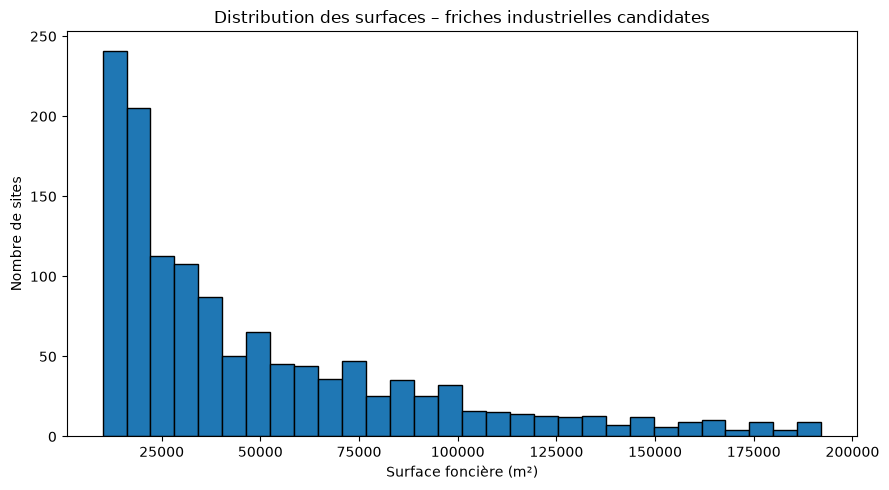

In [ ]:
# Histogramme de la distribution de la surface de la friche

surface_plot = candidates["unite_fonciere_surface"].dropna()
# On affiche 85% des resultats pour garder une meilleure visibilitee
cap = surface_plot.quantile(0.85)

plt.figure(figsize=(9, 5))
plt.hist(surface_plot[surface_plot <= cap], bins=30, edgecolor="black")
plt.title("Distribution des surfaces - friches candidates")
plt.xlabel("Surface fonciere (m2)")
plt.ylabel("Nombre de sites")
plt.tight_layout()
plt.savefig("viz_histogramme_surfaces.png", dpi=150)
plt.show()

print("Image saved: viz_histogramme_surfaces.png")

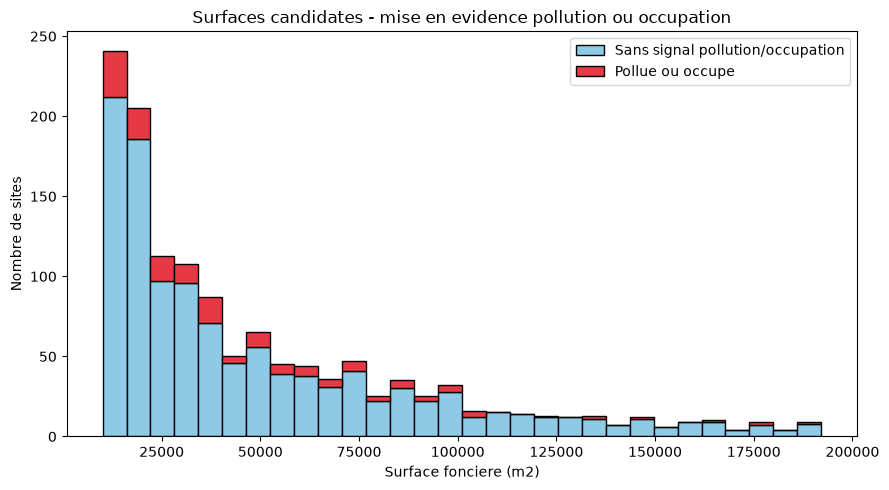

Image saved: viz_histogramme_surfaces_risque.png
Sites pollues ou occupes (dans le graphique): 155
Autres sites (dans le graphique): 1156


In [51]:
# Meme histogramme, mais on met en evidence les sites pollués ou occupés

risk_mask = (
    candidates["sol_pollution_existe"].isin(polluted_labels)
    | candidates["site_occupation"].isin(occupied_labels)
)

surface_all = candidates.loc[~risk_mask, "unite_fonciere_surface"].dropna()
surface_risk = candidates.loc[risk_mask, "unite_fonciere_surface"].dropna()

# meme borne que l'histogramme précédent pour comparer facilement
surface_all = surface_all[surface_all <= cap]
surface_risk = surface_risk[surface_risk <= cap]

bins = 30
plt.figure(figsize=(9, 5))
plt.hist(
    [surface_all, surface_risk],
    bins=bins,
    stacked=True,
    edgecolor="black",
    color=["#8ecae6", "#e63946"],
    label=["Sans signal pollution/occupation", "Pollue ou occupe"],
)
plt.title("Surfaces candidates - mise en evidence pollution ou occupation")
plt.xlabel("Surface fonciere (m2)")
plt.ylabel("Nombre de sites")
plt.legend()
plt.tight_layout()
plt.savefig("viz_histogramme_surfaces_risque.png", dpi=150)
plt.show()

print("Image saved: viz_histogramme_surfaces_risque.png")
print("Sites pollues ou occupes (dans le graphique):", len(surface_risk))
print("Autres sites (dans le graphique):", len(surface_all))